In [7]:
import requests
import pandas as pd
import geopandas as gpd
import partridge as ptg
import numpy as np
import matplotlib.pyplot as plt
import folium

In [ ]:
ptg.load_feed

In [52]:
# Mobility Data Auth - not using for now
"""
# Get Access Token
with open("./rawData/MOBILITY_DATA_REFRESH_KEY", "r") as f:
    refresh_token = f.read()
access_key_request_data = {"refresh_token": refresh_token}
r = requests.post(
    "https://api.mobilitydatabase.org/v1/tokens/access",
    json=access_key_request_data,
    headers={'Content-Type': 'application/json'}
)
access_token = ""
if r.status_code == 200:
    access_token = r.json()["access_token"]
else:
    raise RuntimeError(f"Error: {r.text}")"""

'\n# Get Access Token\nwith open("./rawData/MOBILITY_DATA_REFRESH_KEY", "r") as f:\n    refresh_token = f.read()\naccess_key_request_data = {"refresh_token": refresh_token}\nr = requests.post(\n    "https://api.mobilitydatabase.org/v1/tokens/access",\n    json=access_key_request_data,\n    headers={\'Content-Type\': \'application/json\'}\n)\naccess_token = ""\nif r.status_code == 200:\n    access_token = r.json()["access_token"]\nelse:\n    raise RuntimeError(f"Error: {r.text}")'

In [213]:
def get_percentile_headway_minutes_for_stop(feed, stop_id, time_start, time_end, percentile, trip_cutoff=5):
    #TODO: figure out a good way to handle services where there are a substantial nuber of trips but they are all grouped around a short time period
    trip_ids_serving_stop = feed.stop_times.loc[feed.stop_times.stop_id == stop_id, "trip_id"]
    df_route_and_direction_ids_serving_stop = feed.trips.loc[ # inefficient?
        feed.trips.trip_id.isin(trip_ids_serving_stop),
        ["route_id", "direction_id"],
    ].drop_duplicates()
    df_route_and_direction_ids_serving_stop["route_direction_combined"] = df_route_and_direction_ids_serving_stop["route_id"].astype(str) + "_" + df_route_and_direction_ids_serving_stop["direction_id"].astype(str)
    df_route_and_direction_ids_serving_stop.set_index("route_direction_combined", inplace=True)
    def get_percentile_headway_for_route_direction(route_id, direction_id):
        trips_for_specified_route_direction = feed.trips.loc[
            (feed.trips.route_id == route_id) & (feed.trips.direction_id == direction_id),
            "trip_id"
        ]
        df_stop_times_for_specified_stop_route_direction_time = feed.stop_times[ # inefficient?
            ( 
                (feed.stop_times.stop_id == stop_id)
                & feed.stop_times.trip_id.isin(trips_for_specified_route_direction)
                & (feed.stop_times.departure_time > time_start)
                & (feed.stop_times.departure_time < time_end)
            )
        ].sort_values("departure_time")
        if len(df_stop_times_for_specified_stop_route_direction_time) < trip_cutoff:
            print(
                f"WARN: {route_id}, {stop_id} has too few trips ({len(df_stop_times_for_specified_stop_route_direction_time)}) for a meaningful headway to be calculated, returning na"
            )
            return np.nan
        headway_seconds = df_stop_times_for_specified_stop_route_direction_time.departure_time[1:].values - df_stop_times_for_specified_stop_route_direction_time.departure_time[:-1].values
        headway_minutes = (headway_seconds / 60.).round().astype(int)
        return np.percentile(headway_minutes, percentile)
    df_route_and_direction_ids_serving_stop["percentile_headways"] = df_route_and_direction_ids_serving_stop.apply(
        lambda x: get_percentile_headway_for_route_direction(x["route_id"], x["direction_id"]),
        axis=1
    )
    if df_route_and_direction_ids_serving_stop["percentile_headways"].isna().all():
        return np.nan
    return dict(df_route_and_direction_ids_serving_stop["percentile_headways"].dropna())

def get_headway_histogram(feed, stop_id, time_start, time_end):
    trip_ids_serving_stop = feed.stop_times.loc[feed.stop_times.stop_id == stop_id, "trip_id"]
    df_route_and_direction_ids_serving_stop = feed.trips.loc[
        feed.trips.trip_id.isin(trip_ids_serving_stop),
        ["route_id", "direction_id"],
    ]
    test_route = df_route_and_direction_ids_serving_stop.route_id.iloc[0]
    test_direction = df_route_and_direction_ids_serving_stop.direction_id.iloc[0]
    trips_for_specified_route_direction = feed.trips.loc[
            (feed.trips.route_id == test_route) & (feed.trips.direction_id == test_direction),
            "trip_id"
    ].unique()
    df_stop_times_for_specified_stop_route_direction_time = feed.stop_times[
        (
            (feed.stop_times.stop_id == stop_id)
            & feed.stop_times.trip_id.isin(trips_for_specified_route_direction)
            & (feed.stop_times.departure_time > time_start)
            & (feed.stop_times.departure_time < time_end)
        )
    ].sort_values("departure_time")
    headway_seconds = df_stop_times_for_specified_stop_route_direction_time.departure_time[1:].values - df_stop_times_for_specified_stop_route_direction_time.departure_time[:-1].values
    headway_minutes = (headway_seconds / 60.).round().astype(int)
    print(test_route)
    plt.hist(headway_minutes)

In [218]:
feed2.routes.loc[feed2.routes.route_id == "51-13183"]

,route_id,route_short_name,route_long_name,route_desc,route_type,route_color,route_text_color,route_url
13,51-13183,51,Metro Local Line,WESTLAKE/MCARTHUR PK STA-DTWN LA-CSU DH VIA AV...,3,NaN,NaN,NaN


In [220]:
MIDDAY_START = 10*60*60
MIDDAY_END = 15*60*60
test_stop = feed2.stops.loc[feed2.stops.stop_name == "Venice / Vermont", "stop_id"].iloc[0]
get_percentile_headway_minutes_for_stop(
    feed2,
    stop_id=test_stop,
    time_start=MIDDAY_START,
    time_end=MIDDAY_END,
    percentile=80
)

{'33-13183_1': 8.0}

33-13183


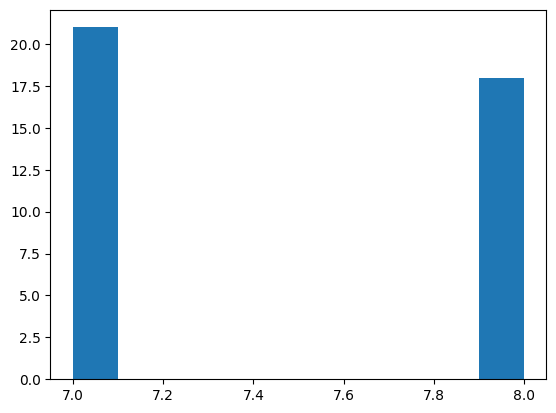

In [221]:
get_headway_histogram(
    feed2,
    test_stop,
    MIDDAY_START,
    MIDDAY_END,   
)

In [222]:
df_stops = feed2.stops.copy()
df_stops["headway"] = feed2.stops.stop_id.map(
    lambda stop_id: get_percentile_headway_minutes_for_stop(
        feed=feed2,
        stop_id=stop_id, 
        time_start=MIDDAY_START, 
        time_end=MIDDAY_END,
        percentile=80
    )
)
df_stops["min_headway"] = df_stops["headway"].map(lambda x: np.nan if type(x) is not dict else min(x.values()))
df_stops.to_csv("test.csv")
df_stops

WARN: 236-13183, 33 has too few trips (4) for a meaningful headway to be calculated, returning na
WARN: 20-13183, 38 has too few trips (0) for a meaningful headway to be calculated, returning na
WARN: 20-13183, 38 has too few trips (0) for a meaningful headway to be calculated, returning na
WARN: 4-13183, 38 has too few trips (0) for a meaningful headway to be calculated, returning na
WARN: 4-13183, 38 has too few trips (0) for a meaningful headway to be calculated, returning na
WARN: 115-13183, 51 has too few trips (0) for a meaningful headway to be calculated, returning na
WARN: 211-13183, 141 has too few trips (1) for a meaningful headway to be calculated, returning na
WARN: 211-13183, 147 has too few trips (1) for a meaningful headway to be calculated, returning na
WARN: 115-13183, 176 has too few trips (0) for a meaningful headway to be calculated, returning na
WARN: 40-13183, 312 has too few trips (0) for a meaningful headway to be calculated, returning na
WARN: 40-13183, 313 has

KeyboardInterrupt: 

In [195]:
gdf_stops = gpd.GeoDataFrame(
    df_stops, 
    geometry=gpd.points_from_xy(df_stops.stop_lon, df_stops.stop_lat),
    crs=4326
)
gdf_stops.to_file("test.geojson")

In [144]:
feed2.trips.trip_id.isin(feed2.stop_times.loc[feed2.stop_times.stop_id == test_stop, "trip_id"]).any()

True

In [146]:
feed2.trips

,route_id,service_id,trip_id,trip_headsign,direction_id,block_id,shape_id
0,31,1,6,SMV A Line Station via Foothill Blvd,0,3406,1
1,40,1,7,SMV A Line Station,0,3407,115
2,32,1,8,Northwest Pasadena,1,3408,61
3,40,1,9,Old Pasadena,1,3409,116
4,32,1,10,SMV A Line Station,0,3410,3
...,...,...,...,...,...,...,...
354,20cc,1,2387,Fair Oaks & Woodbury,0,2940,10
355,20cc,1,2388,Fair Oaks & Woodbury,0,2950,10
356,20cc,1,2392,Fair Oaks & Woodbury,0,2960,10
357,20cc,1,2393,Fair Oaks & Woodbury,0,2970,10


,route_id,service_id,trip_id,trip_headsign,direction_id,block_id,shape_id
0,31,1,6,SMV A Line Station via Foothill Blvd,0,3406,1


In [80]:
(feed2.trips.trip_id == "1731").any()

True

In [35]:
feed2.trips["route_id"].unique()

array(['31', '40', '32', '51', '60', '10', '52', '20cw', '20cc'],
      dtype=object)

In [24]:
ptg.load_feed(inpath, view).routes

,route_id,agency_id,route_short_name,route_long_name,route_type,route_color,route_text_color
0,10,1,10,Old Pasadena - PCC - Allen Station,3,C5003E,FFFFFF


In [43]:
# Find trips overlapping the time window
trip_ids = feed.stop_times[
    (feed.stop_times.arrival_time >= 6*60*60) # 6am
    & (feed.stop_times.arrival_time <= 9*60*60) # 9am
].trip_id.unique()
# Collect the stop_ids for each trip
trip_stops = []
for _, stimes in feed.stop_times[feed.stop_times.trip_id.isin(trip_ids)].groupby("trip_id"):
    trip_stops.append(set(stimes.stop_id))

# Find stop_ids shared between all trips
common_stops = set(trip_stops[0])
for stop_ids in trip_stops[1:]:
    common_stops &= stop_ids

assert common_stops

# Choose one stop to focus on
subject_stop_id = list(common_stops)[0]

feed.stops[feed.stops.stop_id==subject_stop_id]
stimes = feed.stop_times[feed.stop_times.stop_id==subject_stop_id].sort_values("arrival_time")
stimes.head()

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,timepoint
6,470,20731.0,20731.0,36,7,NaN,0
396,761,22061.0,22061.0,36,7,NaN,0
32,472,23261.0,23261.0,36,7,NaN,0
812,1320,24281.0,24281.0,36,7,NaN,0
422,914,25241.0,25241.0,36,7,NaN,0


In [21]:
get_percentile_headway_minutes_for_stop_times(feed, list(common_stops)[4], 10)

16.0

In [12]:
stimes

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,timepoint
6,470,20731.0,20731.0,36,7,NaN,0
396,761,22061.0,22061.0,36,7,NaN,0
32,472,23261.0,23261.0,36,7,NaN,0
812,1320,24281.0,24281.0,36,7,NaN,0
422,914,25241.0,25241.0,36,7,NaN,0
58,501,26212.0,26212.0,36,7,NaN,0
838,1323,27292.0,27292.0,36,7,NaN,0
448,979,28252.0,28252.0,36,7,NaN,0
84,503,29212.0,29212.0,36,7,NaN,0
864,1325,30232.0,30232.0,36,7,NaN,0


In [17]:
headway_seconds = stimes.arrival_time[1:].values - stimes.arrival_time[:-1].values
headway_minutes = (headway_seconds / 60.).round().astype(int)

np.percentile(headway_minutes, 80)

19.0

In [7]:
feed

In [ ]:
# See this to try and make a request

In [6]:
import folium.raster_layers
transitland_key = "iMGHYCuvlmhChyTvB9gmQuDonmXnj91W"

m = folium.Map(
    tiles="https://transit.land/api/v2/tiles/stops/tiles/{z}/{x}/{y}.pbf?apikey="+transitland_key,
    attr="transitland"

)
transitland_layer = folium.raster_layers.TileLayer(
    tiles="https://transit.land/api/v2/tiles/stops/tiles/{z}/{x}/{y}.pbf?apikey="+transitland_key,
    attr="transitland"
    )
#transitland_layer.add_to(m)
m